# 1: The five Pleiades stars

In this notebook I load the velociscuti emulator, fit the five $\delta$ Scuti stars of the paper, and combine their ages into one age for the cluster. Every setting is the one used in the paper, so the numbers at the end should agree with the published ones to within the sampling noise.

On one core of my laptop (an Apple M2 Pro), a fit at the paper's settings took between 45 seconds and 1.5 minutes per star. For a quick look, put lighter settings in `run_settings` below. Most of the time goes into reaching the paper's `dlogz=0.1`: with `dlogz=0.5` a fit takes a few seconds.

In [1]:
import json

import numpy as np
import matplotlib.pyplot as plt

from velociscuti import load_emulator, velociscuti_sampler, posterior_plot, posterior_summary, cluster_age

## The emulator

The emulator is a neural network trained on a grid of rotating stellar models computed with MESA, with pulsation frequencies from StORM. It takes four inputs: initial mass `m` in $M_\odot$, initial metal mass fraction `z`, age `Myr` in Myr and equatorial rotation velocity `v_eq` in km s$^{-1}$. It returns 232 outputs: 14 stellar and seismic quantities, such as $T_{\rm eff}$, $\log L$ and the large frequency separation, and 218 pulsation frequencies in cycles per day.

In [2]:
emulator = load_emulator()

theta = np.array([[1.7, 0.0152, 112.8, 50.0]])   ## m, z, Myr, v_eq
prediction = emulator.predict(theta)[0]

for name in ['teff', 'log_L', 'Dnu', 'n1ell0m0', 'n5ell1m-1', 'n5ell1m0', 'n5ell1m1']:
    print(f'{name:10s} {prediction[emulator.output_cols.index(name)]:.4f}')

[load_emulator] velociscuti loaded: 4 inputs, 232 outputs
teff       8241.5098
log_L      0.9673
Dnu        7.2106
n1ell0m0   22.1068
n5ell1m-1  50.4768
n5ell1m0   51.1175
n5ell1m1   51.7756


The frequency columns are named by radial order, degree and azimuthal order: `n5ell1m-1` is the p mode with $n=5$, $\ell=1$, $m=-1$. The g modes are `ng1...` and `ng2...`, and the f modes are stored as `ng0...`. Frequencies are in the observer's frame, and positive $m$ is prograde: in the rotating model above, the $m=+1$ component lies above $m=0$ in frequency and the $m=-1$ component lies below it.

The full list of outputs, and the range of inputs the emulator was trained on, are in `velociscuti/model/velociscuti_info.md`. `predict` raises an error for inputs outside that range, because a prediction there would be an extrapolation.

## The sampler

The sampler holds the priors and the likelihood. With no other arguments it uses the priors of the paper: uniform in mass from 1.4 to 2.5 $M_\odot$, uniform in age from 50 to 200 Myr, uniform in $v_{\rm eq}$ from 0 to 200 km s$^{-1}$, and a Gaussian in $Z$ with mean 0.0152 and standard deviation 0.0019, truncated to the range of the grid. The $Z$ prior is based on the spectroscopic metallicity of the Pleiades measured by [Soderblom et al. (2009)](https://ui.adsabs.harvard.edu/abs/2009AJ....138.1292S).

The sampler also gives zero likelihood to any model that rotates faster than half of its critical rate (`omega_ratio_max=0.5`), the rotation domain adopted in the paper.

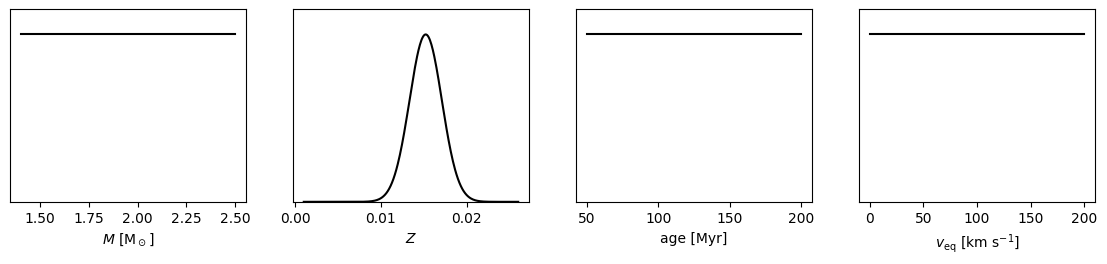

In [3]:
sampler = velociscuti_sampler(emulator)

labels = [r'$M$ [M$_\odot$]', r'$Z$', 'age [Myr]', r'$v_{\rm eq}$ [km s$^{-1}$]']
fig, axes = plt.subplots(1, 4, figsize=(14, 2.5))
for ax, prior, label in zip(axes, sampler.priors, labels):
    lo, hi = prior.limits
    x = np.linspace(lo, hi, 300)
    ax.plot(x, prior.pdf(x), color='black')
    ax.set_ylim(0, 1.15 * prior.pdf(x).max())
    ax.set_xlabel(label)
    ax.set_yticks([])
plt.show()

## One star: V624 Tau

Each star has a folder under `stars/`. `V624_Tau.json` holds the effective temperature, `V624_Tau_modes.csv` the observed frequencies with their mode identifications, and `V624_Tau_covariance.npz` the covariance matrix used in the paper.

The likelihood is a multivariate Gaussian over the identified frequencies. Its covariance matrix is the sum of the observational variances and the covariance of the emulator's error, which includes the correlations of that error between modes. $T_{\rm eff}$ enters as a separate Gaussian term, whose variance is the sum of the observational and emulator variances. Notebook 2 shows how the covariance matrix is built.

`run_settings` goes straight to UltraNest's `run`. Left empty, the sampler uses the settings of the paper: 1000 live points, `dlogz=0.1`, `min_ess=1000`, `frac_remain=0.01`, at most $10^7$ likelihood calls, and random seed 42.

In [4]:
run_settings = dict()   ## for a quick look: dict(min_num_live_points=200, dlogz=0.5, min_ess=200, frac_remain=0.1)

In [5]:
results = {}
results['V624_Tau'] = sampler('V624_Tau', save_as='V624_Tau_results.npz', **run_settings)

[velociscuti_sampler] sampling posterior of V624_Tau!
[velociscuti_sampler] 26 identified modes, teff = 7960 K, rotation limit = 0.5
[ultranest] Sampling 1000 live points from prior ...


[ultranest] Explored until L=-4e+01   [-40.7458..-40.7456]*| it/evals=21800/53008 eff=41.9166% N=1000       00  0 
[ultranest] Likelihood function evaluations: 53043
[ultranest]   logZ = -57.88 +- 0.07808
[ultranest] Effective samples strategy satisfied (ESS = 5334.0, need >1000)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.04 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy wants 1511 minimum live points (dlogz from 0.07 to 0.16, need <0.1)
[ultranest]   logZ error budget: single: 0.12 bs:0.08 tail:0.01 total:0.08 required:<0.10
[ultranest] Widening roots to 1511 live points (have 1000 already) ...
[ultranest] Sampling 511 live points from prior ...
[ultranest] Explored until L=-4e+01   [-40.7468..-40.7468]*| it/evals=33017/80916 eff=41.0496% N=1511        1    
[ultranest] Likelihood function evaluations: 80916
[ultranest]   logZ = -57.98 +- 0.07634
[ultranest] Effective samples strategy satisfied (ESS = 8140.2, need >1000)
[ultranest] Posterior 

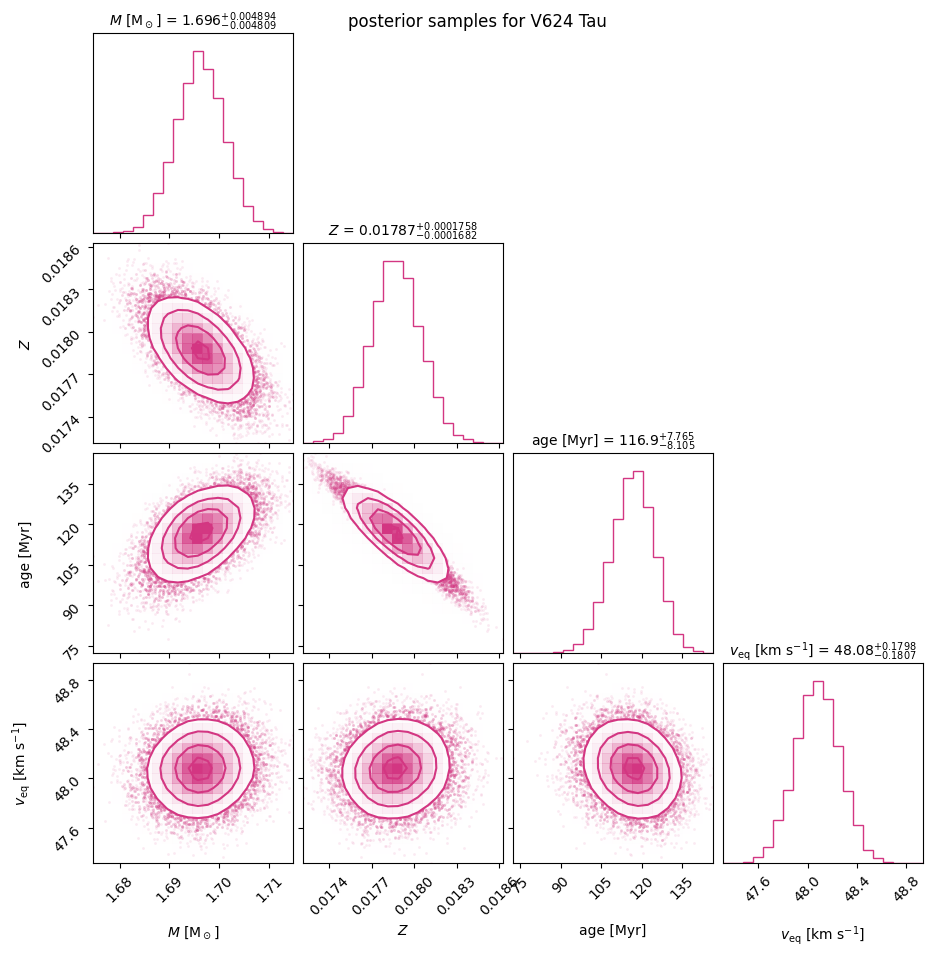

In [6]:
posterior_plot(results['V624_Tau'], star_name='V624 Tau');   ## include_prior=True draws the prior underneath

## The other four

The same call fits the other stars. I switch off the live display so that the output stays short. Each result is saved in the star's folder and can be read back later with `load_results`.

In [7]:
for star in ['V647_Tau', 'V1187_Tau', 'HD23157', 'HD23325']:
    results[star] = sampler(star, save_as=f'{star}_results.npz', show_status=False, viz_callback=False, **run_settings)

[velociscuti_sampler] sampling posterior of V647_Tau!
[velociscuti_sampler] 20 identified modes, teff = 8055 K, rotation limit = 0.5
[ultranest] Sampling 1000 live points from prior ...
[ultranest] Explored until L=-8e+01  
[ultranest] Likelihood function evaluations: 71251
[ultranest]   logZ = -99.71 +- 0.09688
[ultranest] Effective samples strategy satisfied (ESS = 5240.6, need >1000)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.04 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy wants 1531 minimum live points (dlogz from 0.08 to 0.22, need <0.1)
[ultranest]   logZ error budget: single: 0.13 bs:0.10 tail:0.01 total:0.10 required:<0.10
[ultranest] Widening roots to 1531 live points (have 1000 already) ...
[ultranest] Sampling 531 live points from prior ...
[ultranest] Explored until L=-8e+01  
[ultranest] Likelihood function evaluations: 110789
[ultranest]   logZ = -99.79 +- 0.07755
[ultranest] Effective samples strategy satisfied (ESS = 8140.5, n

## Comparison with the paper

Each star folder also holds `<name>_paper.json`, the posterior summary of the fit adopted in the paper. Nested sampling is a Monte Carlo method, and the published fits ran on different hardware, so I expect agreement to within the sampling noise. For the median ages that noise is a few tenths of a Myr.

In [8]:
def fmt(summary, digits):
    median, p16, p84 = summary['median'], summary['p16'], summary['p84']
    return f'{median:.{digits}f} +{p84 - median:.{digits}f} -{median - p16:.{digits}f}'

digits = {'m': 3, 'z': 4, 'Myr': 1, 'v_eq': 1}
for star in results:
    here = posterior_summary(results[star])
    with open(f'stars/{star}/{star}_paper.json', 'r') as fp:
        paper = json.load(fp)['params']
    print(star)
    for name in ['m', 'z', 'Myr', 'v_eq']:
        print(f'    {name:5s} here: {fmt(here[name], digits[name]):>22s}    paper: {fmt(paper[name], digits[name]):>22s}')

V624_Tau
    m     here:    1.696 +0.005 -0.005    paper:    1.696 +0.005 -0.005
    z     here: 0.0179 +0.0002 -0.0002    paper: 0.0179 +0.0002 -0.0002
    Myr   here:        116.9 +7.8 -8.1    paper:        116.9 +7.7 -8.2
    v_eq  here:         48.1 +0.2 -0.2    paper:         48.1 +0.2 -0.2
V647_Tau
    m     here:    1.721 +0.006 -0.006    paper:    1.721 +0.006 -0.006
    z     here: 0.0192 +0.0002 -0.0002    paper: 0.0192 +0.0002 -0.0002
    Myr   here:        113.4 +9.3 -9.3    paper:        113.7 +9.3 -9.6
    v_eq  here:         40.3 +0.2 -0.2    paper:         40.3 +0.2 -0.2
V1187_Tau
    m     here:    1.665 +0.011 -0.011    paper:    1.665 +0.011 -0.010
    z     here: 0.0177 +0.0003 -0.0003    paper: 0.0177 +0.0003 -0.0004
    Myr   here:      112.4 +17.2 -17.5    paper:      112.6 +17.5 -17.4
    v_eq  here:         40.4 +0.3 -0.3    paper:         40.4 +0.3 -0.3
HD23157
    m     here:    1.514 +0.006 -0.005    paper:    1.514 +0.007 -0.006
    z     here: 0.0189 +0.00

## The age of the cluster

The five stars belong to one cluster, so they share one age. In the paper, each star's age posterior is smoothed with a Gaussian kernel and the five curves are multiplied, which treats the stars as coeval and their posteriors as independent. `cluster_age` does the same.

cluster age: 113.4 +4.5 -4.5 Myr
paper:       113.3 +4.5 -4.5 Myr


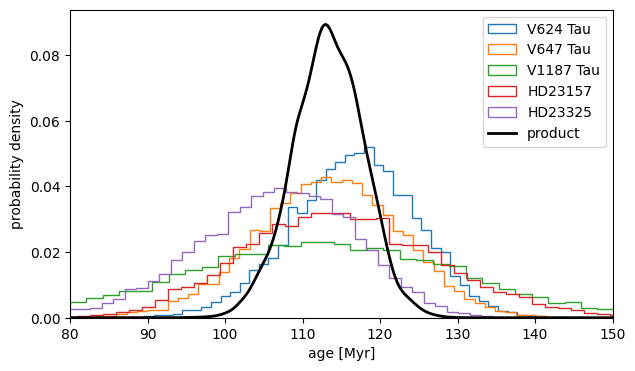

In [9]:
age = cluster_age(results)
print(f"cluster age: {age['median']:.1f} +{age['plus']:.1f} -{age['minus']:.1f} Myr")
print('paper:       113.3 +4.5 -4.5 Myr')

fig, ax = plt.subplots(figsize=(7, 4))
for star in results:
    ax.hist(results[star]['samples'][:, 2], bins=60, density=True, histtype='step', label=star.replace('_', ' '))
ax.plot(age['ages'], age['density'], color='black', lw=2, label='product')
ax.set_xlabel('age [Myr]')
ax.set_ylabel('probability density')
ax.set_xlim(80, 150)
ax.legend()
plt.show()

## What this age is conditional on

The interval above is statistical. It is conditional on the mode identifications, the priors, the emulator and its covariance, and the stellar models behind the grid, which were computed with a single set of input physics. A change in any of these can shift the age, and the interval does not include such shifts.